# sample2 - 分類（アイリス）

PyTorch の sample3 と同じ題材で **TensorFlow / Keras** の書き方を比較します。  
PyTorch では学習ループを自分で書きましたが、Keras では `model.fit()` 一行で完結します。

| ステップ | 内容 |
|----------|------|
| 1 | データ準備 |
| 2 | モデル定義 |
| 3 | 学習 |
| 4 | 評価・可視化 |

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # GPU を無効化して CPU で実行
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print("TensorFlow:", tf.__version__)

I0000 00:00:1771826686.913149   96299 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1771826687.822448   96299 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.22.0-dev20260222


## 1. データ準備

In [2]:
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

X_train: (120, 4) y_train: (120,)
X_test : (30, 4) y_test : (30,)


## 2. モデル定義

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8,  activation='relu'),
    tf.keras.layers.Dense(3,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/home/user/HOME/sample/sample_python/403_TensorFlowKeras/env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. 学習

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0  # ログ非表示
)
print("学習完了")

学習完了


## 4. 評価・可視化

In [5]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"テスト Loss    : {loss:.4f}")
print(f"テスト Accuracy: {accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print("\n詳細レポート:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

テスト Loss    : 0.0514
テスト Accuracy: 1.0000

詳細レポート:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



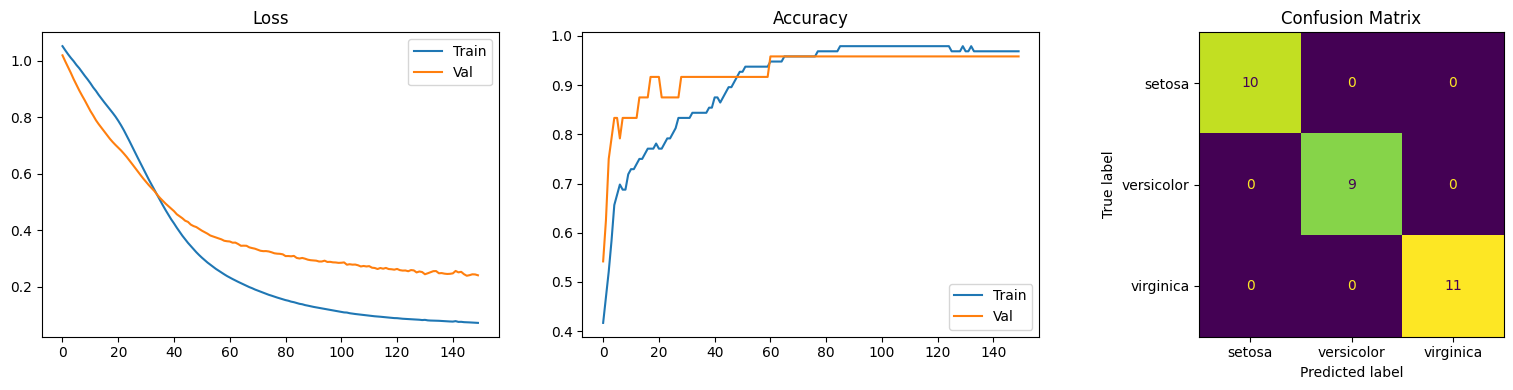

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

# 混同行列
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    ax=axes[2], colorbar=False
)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()